<a href="https://colab.research.google.com/github/Alinberlian/iris-bootstrap-eda/blob/main/Data_Pre_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Berlian Mumtajmia L
2304010027

#Tugas Pre-Processing Data: Analisis Penjualan Mobil Historis

Konteks Data
Dataset ini (historical_automobile_sales.csv) berisi rekaman historis penjualan mobil di berbagai kota beserta faktor-faktor makroekonomi yang mempengaruhinya dari tahun 1980 hingga 2023.

Tujuan Analisis: Memahami variabel apa saja yang berdampak pada volume penjualan mobil (Automobile_Sales).

Karakteristik Data: Memiliki 528 observasi dan 15 variabel yang terdiri dari data runtun waktu (Date, Year, Month), indikator makroekonomi (GDP, Unemployment Rate, Consumer Confidence, Recession), serta data pasar (Price, Advertising Expenditure, Competition).

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#1. Load Dataset

Menampilkan 5 data pertama untuk memahami struktur dataset.

In [50]:
df = pd.read_csv('historical_automobile_sales.csv')
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


# 2. DATA UNDERSTANDING

Cek Struktur Data

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    object 
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    object 
 3   Recession                528 non-null    int64  
 4   Consumer_Confidence      528 non-null    float64
 5   Seasonality_Weight       528 non-null    float64
 6   Price                    528 non-null    float64
 7   Advertising_Expenditure  528 non-null    int64  
 8   Competition              528 non-null    int64  
 9   GDP                      528 non-null    float64
 10  Growth_Rate              528 non-null    float64
 11  unemployment_rate        528 non-null    float64
 12  Automobile_Sales         528 non-null    float64
 13  Vehicle_Type             528 non-null    object 
 14  City                     5

Statistik Deskriptif

In [52]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,2001.500000,0.214015,101.140170,0.575795,24964.991956,3067.456439,6.064394,40.073903,-0.242001,2.453977,2352.718068
std,12.710467,0.410526,10.601154,0.454477,4888.073433,1139.564637,1.968350,16.249714,0.861268,1.119019,1645.321284
min,1980.000000,0.000000,73.900000,0.000000,8793.663000,1009.000000,3.000000,12.508000,-4.227601,1.000000,102.000000
25%,1990.750000,0.000000,94.035000,0.250000,21453.300500,2083.500000,4.000000,27.237500,-0.574049,1.600000,793.950000
50%,2001.500000,0.000000,100.740000,0.500000,25038.691500,3072.000000,6.000000,39.214500,-0.013162,2.300000,2182.600000
75%,2012.250000,0.000000,108.240000,0.750000,28131.684750,4067.250000,8.000000,53.506500,0.388932,2.900000,3614.800000
max,2023.000000,1.000000,131.670000,1.500000,44263.657000,4983.000000,9.000000,70.374000,0.815074,6.000000,21147.000000


# 3. DATA CLEANING

Cek Missing Value

In [53]:
df.isnull().sum()

,0
Date,0
Year,0
Month,0
Recession,0
Consumer_Confidence,0
Seasonality_Weight,0
Price,0
Advertising_Expenditure,0
Competition,0
GDP,0


In [54]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_4216/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Cek Duplikat

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.drop_duplicates(inplace=True)

Menghapus data yang sama agar tidak bias

# 4. VISUALISASI AWAL (EDA)

Distribusi Penjualan Mobil

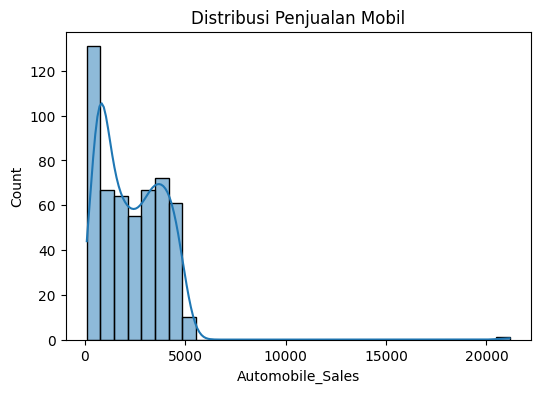

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(df['Automobile_Sales'], kde=True)
plt.title('Distribusi Penjualan Mobil')
plt.show()

Boxplot (Outlier)

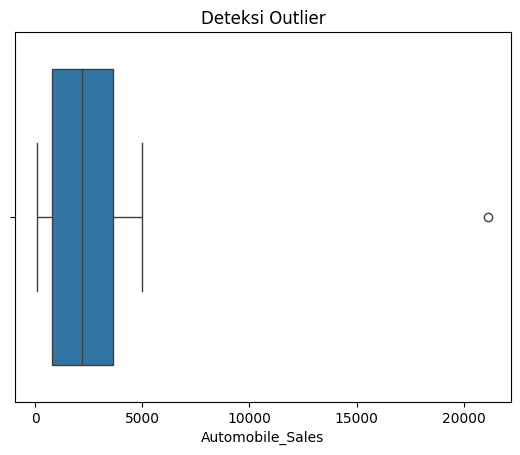

In [58]:
sns.boxplot(x=df['Automobile_Sales'])
plt.title('Deteksi Outlier')
plt.show()

Korelasi

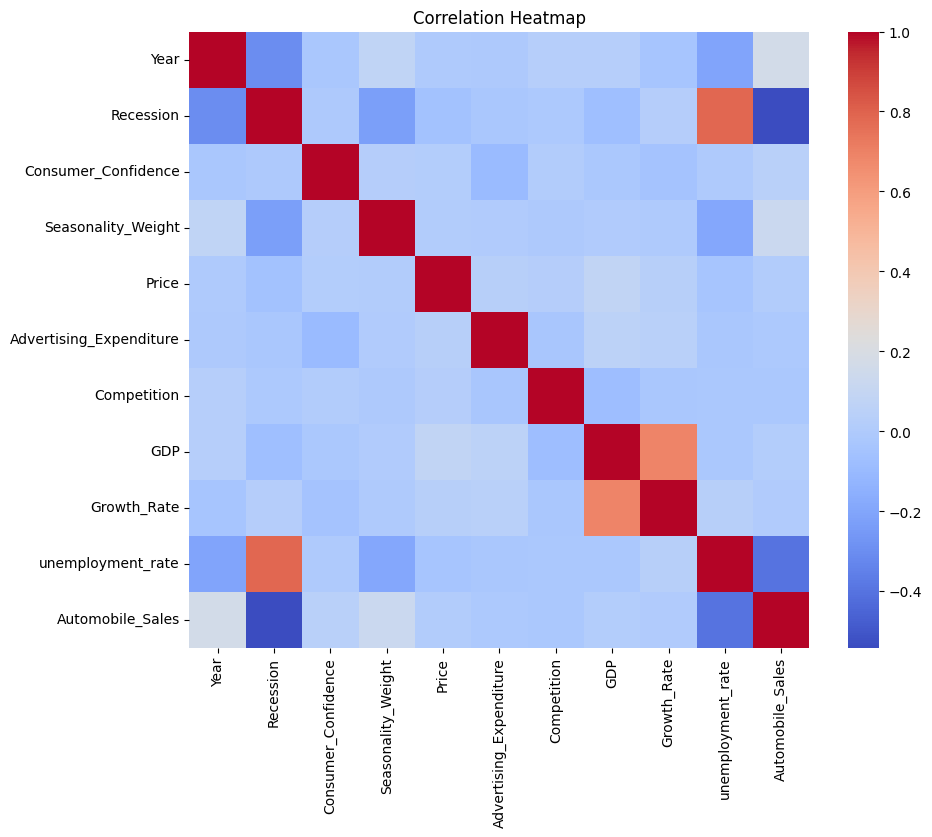

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 5. TRANSFORMASI TARGET

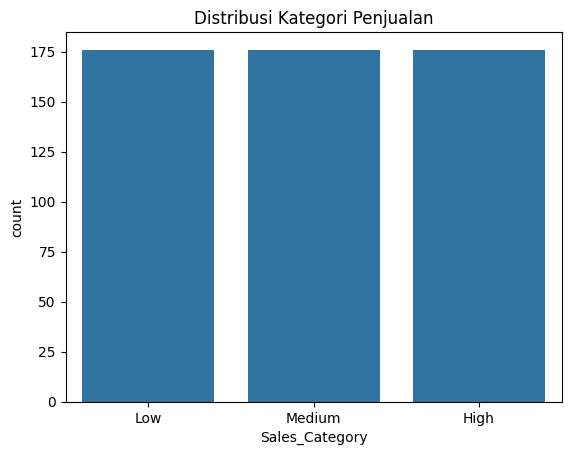

In [60]:
df['Sales_Category'] = pd.qcut(
    df['Automobile_Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
sns.countplot(x=df['Sales_Category'])
plt.title('Distribusi Kategori Penjualan')
plt.show()

# 6. FEATURE ENGINEERING

Drop Kolom Tidak Penting

In [62]:
# Pisahkan target dulu
y = df['Sales_Category']

# Drop target dari fitur
X = df.drop('Sales_Category', axis=1)

# Baru encoding fitur saja
X = pd.get_dummies(X, drop_first=True)

Encoding Kategori

In [63]:
df = pd.get_dummies(df, drop_first=True)

Mengubah data kategori menjadi numerik

# 7. FEATURE SCALING

In [64]:
df.columns

Index(['Year', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight',
       'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate',
       'unemployment_rate',
       ...
       'Month_Sep', 'Vehicle_Type_Mediumfamilycar',
       'Vehicle_Type_Smallfamiliycar', 'Vehicle_Type_Sports',
       'Vehicle_Type_Supperminicar', 'City_Georgia', 'City_Illinois',
       'City_New York', 'Sales_Category_Medium', 'Sales_Category_High'],
      dtype='object', length=558)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8. FINAL CHECK

In [65]:
print("Missing value:\n", df.isnull().sum())
print("\nTipe data:\n", df.dtypes)

Missing value:
 Year                     0
Recession                0
Consumer_Confidence      0
Seasonality_Weight       0
Price                    0
                        ..
City_Georgia             0
City_Illinois            0
City_New York            0
Sales_Category_Medium    0
Sales_Category_High      0
Length: 558, dtype: int64

Tipe data:
 Year                       int64
Recession                  int64
Consumer_Confidence      float64
Seasonality_Weight       float64
Price                    float64
                          ...   
City_Georgia                bool
City_Illinois               bool
City_New York               bool
Sales_Category_Medium       bool
Sales_Category_High         bool
Length: 558, dtype: object


In [66]:
df = df.drop(['Sales_Category_Medium', 'Sales_Category_High'], axis=1)

In [67]:
df['Sales_Category'] = pd.qcut(
    df['Automobile_Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [68]:
y = df['Sales_Category']
X = df.drop(['Sales_Category', 'Automobile_Sales'], axis=1)

In [69]:
X = pd.get_dummies(X, drop_first=True)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
print("Missing value:\n", df.isnull().sum())
print("\nTipe data:\n", df.dtypes)

Missing value:
 Year                          0
Recession                     0
Consumer_Confidence           0
Seasonality_Weight            0
Price                         0
                             ..
Vehicle_Type_Supperminicar    0
City_Georgia                  0
City_Illinois                 0
City_New York                 0
Sales_Category                0
Length: 557, dtype: int64

Tipe data:
 Year                             int64
Recession                        int64
Consumer_Confidence            float64
Seasonality_Weight             float64
Price                          float64
                                ...   
Vehicle_Type_Supperminicar        bool
City_Georgia                      bool
City_Illinois                     bool
City_New York                     bool
Sales_Category                category
Length: 557, dtype: object
